In [1]:
import requests
import pandas as pd
import geopandas as geopd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"]  = 400
plt.style.use('dark_background')

# This script downloads lake regulation data from the SYKE API and processes it.
# It fetches regulated lake information, retrieves detailed data for each lake,
# and saves the data as a GeoPackage file.

In [2]:
def dict_list_to_df(values):
    """ 
    Changes list of dictionaries from ODATA to dataframes
    """
    df = pd.DataFrame(columns=list(values[0].keys()))
    for item in values:
        new = pd.DataFrame([item])
        df = pd.concat([df, new], ignore_index=True)
    return df

In [3]:
# Fetching regulated lake information from the SYKE API.
url = 'https://rajapinnat.ymparisto.fi/api/jarvirajapinta/1.0/odata/JarviSaannostely'

# All the regulated lakes fit into first request, no need to iterate
response = requests.get(url)
if response.status_code == 200:
    content = response.json()
    keys = content.keys()
else:
    raise Exception(f"Error with request, code {response.status_code}")

values = content['value']
regulated_lakes = dict_list_to_df(values)

In [ ]:
regulated_lakes

In [5]:
# Calculate the percentage of missing data by column.
(regulated_lakes.isna().sum() / len(regulated_lakes)) * 100

Jarvi_Id               0.000000
Saannostely_Id         0.000000
VuosiAlku             27.876106
Tilavuus              56.415929
AsteikkoW             52.876106
AsteikkoQ             88.495575
RajaAla               50.221239
RajaYla               53.982301
PinalaRajaAla         70.575221
PinalaRajaYla         67.920354
Lisatieto             13.716814
Tarkoitus             14.159292
TasoKoordinaatisto    62.610619
dtype: float64

In [6]:
lake_ids = list(regulated_lakes.Jarvi_Id)

In [7]:
# Fetch detailed information for each lake.
lakes = []
for lake_id in tqdm(lake_ids):
    lake_url = f"https://rajapinnat.ymparisto.fi/api/jarvirajapinta/1.0/odata/Jarvi({lake_id})"
    try:
        response = requests.get(lake_url)
    except Exception as e:
        with open("error_log.txt", 'a') as error_log:
            error_log.write(f"Lake {lake_id}, error with request:{e}")
            continue
    if response.status_code == 200:
        content = response.json()
        keys = content.keys()
    else:
        with open("error_log.txt", 'a') as error_log:
            error_log.write(f"Lake {lake_id}, error with response, code {response.status_code}")
            continue
    
    lakes.append(content)

  0%|          | 0/452 [00:00<?, ?it/s]

In [9]:
# Create a DataFrame from the lake information.
lake_info = pd.DataFrame(lakes)

In [10]:
# Create the geometry of the measurement locations using ETRS-TM35FIN coordinates
lake_info['geometry'] = geopd.points_from_xy(lake_info.KoordErTmIta, lake_info.KoordErTmPohj)
lake_info = geopd.GeoDataFrame(lake_info, geometry='geometry', crs="EPSG:3067")

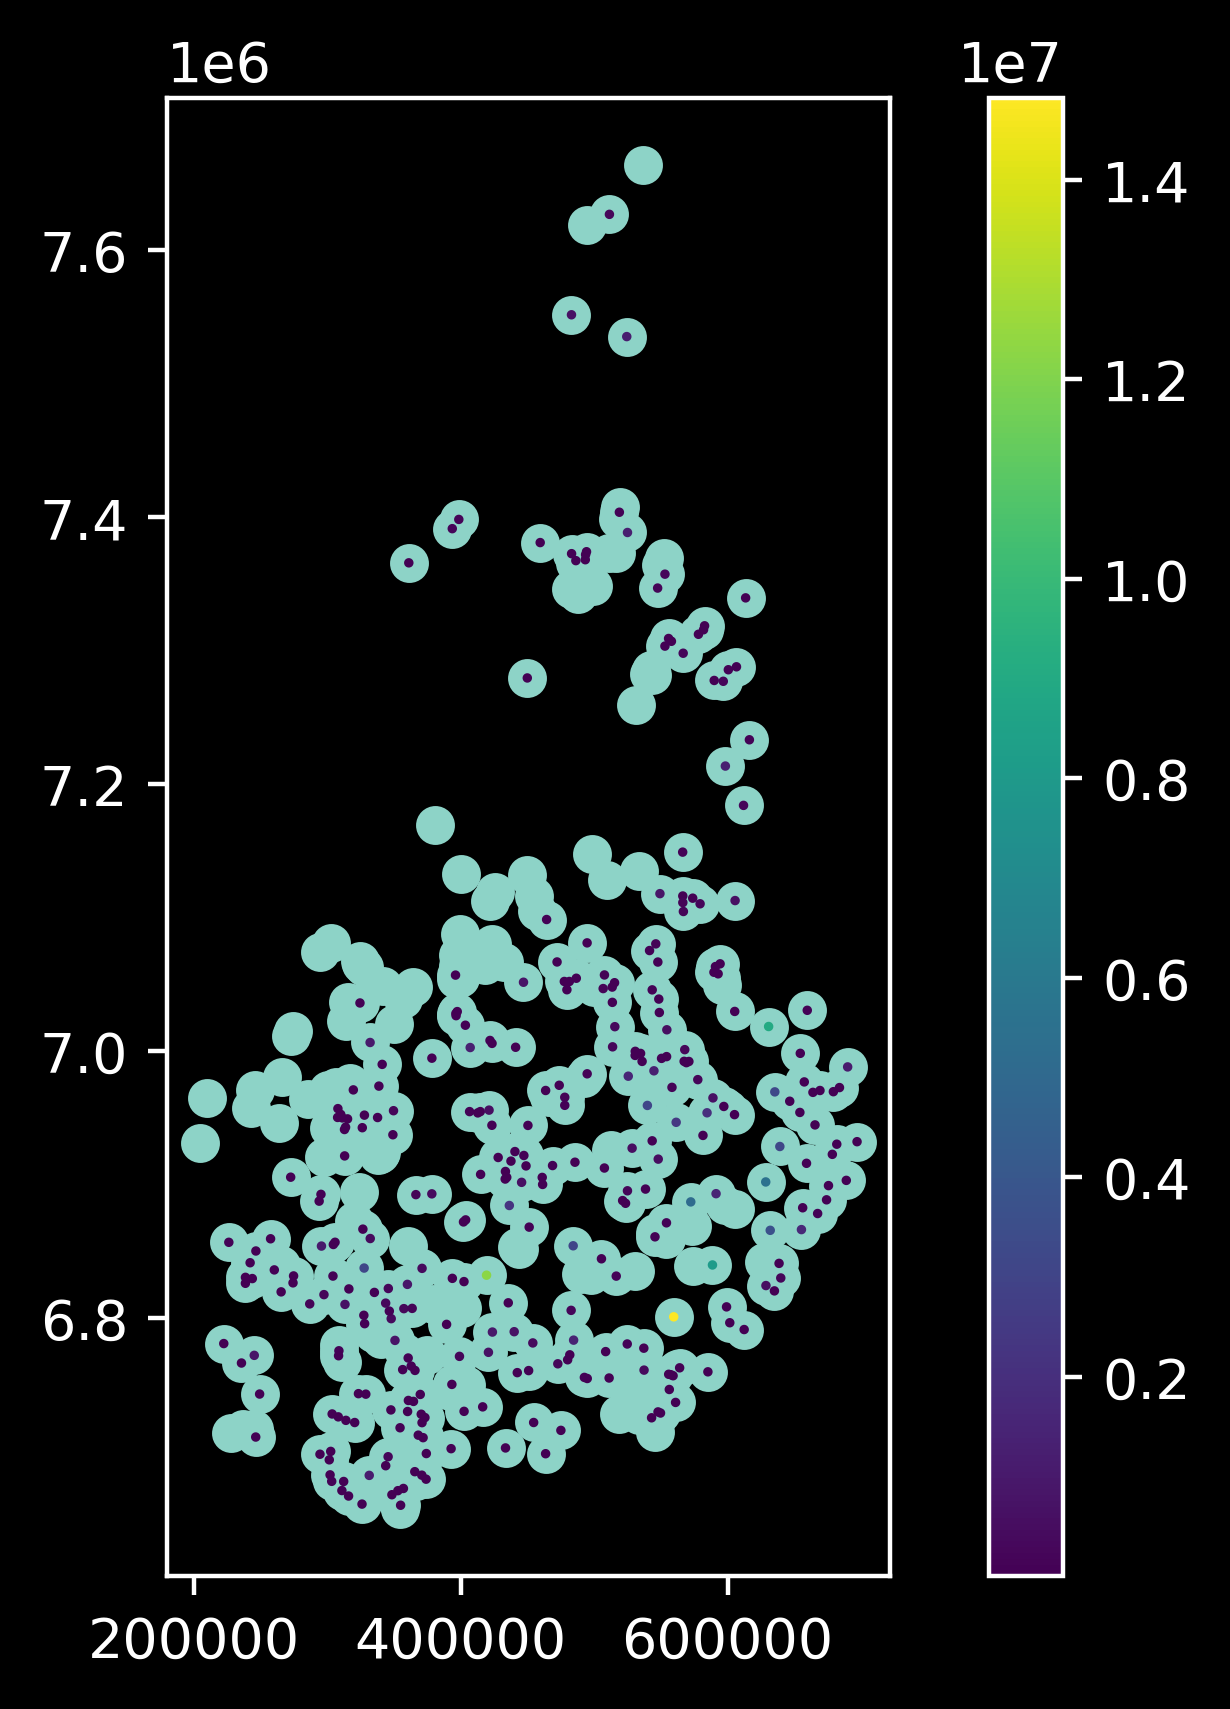

In [11]:
# Plot the lake information.
ax = lake_info.plot()
ax = lake_info.plot('Tilavuus', ax=ax, markersize=0.5, legend=True) # Tilavuus == volume

In [12]:
# Fetch detailed information for each regulation (== saannostely).
regulation_ids = list(regulated_lakes.Saannostely_Id)

types = []
for regulation_id in tqdm(regulation_ids):
    regulation_url = f"https://rajapinnat.ymparisto.fi/api/jarvirajapinta/1.0/odata/Saannostely({regulation_id})"
    try:
        response = requests.get(regulation_url)
    except Exception as e:
        error_count += 1
        with open("error_log.txt", 'a') as error_log:
            error_log.write(f"Lake {regulation_id}, error with request:{e}")
            continue
    if response.status_code == 200:
        content = response.json()
        keys = content.keys()
    else:
        error_count += 1
        with open("error_log.txt", 'a') as error_log:
            error_log.write(f"Lake {regulation_id}, error with response, code {response.status_code}")
            continue
    
    types.append(content)
    
# Create a DataFrame from the regulation type information.
type_info = pd.DataFrame(types)

  0%|          | 0/452 [00:00<?, ?it/s]

In [13]:
type_info

,odata.metadata,Saannostely_Id,Nimi,H_Kunta_Id,KuntaNimi,H_Vesal_Id,VesalNimi,H_Ely_Id,ElyNimi,Valtion,LuvanhaltijaValtio_Id,SaannostelyTyyppi_Id
0,https://rajapinnat.ymparisto.fi/api/jarvirajap...,245,"Sääperi, Tohmajärvi",None,None,None,None,1007,Pohjois-Karjalan ELY,False,NaN,1.0
1,https://rajapinnat.ymparisto.fi/api/jarvirajap...,222,"Tanikan säännöstely, Joensuu",None,None,None,None,1007,Pohjois-Karjalan ELY,False,NaN,1.0
2,https://rajapinnat.ymparisto.fi/api/jarvirajap...,90,"Loitimon ja Melajärven säännöstely, Joensuu",None,None,None,None,1007,Pohjois-Karjalan ELY,False,NaN,1.0
3,https://rajapinnat.ymparisto.fi/api/jarvirajap...,228,"Ylisen säännöstely, Joensuu",None,None,None,None,1007,Pohjois-Karjalan ELY,False,NaN,1.0
4,https://rajapinnat.ymparisto.fi/api/jarvirajap...,7,"Eimisjärven säännöstely, Joensuu",None,None,None,None,1007,Pohjois-Karjalan ELY,False,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
447,https://rajapinnat.ymparisto.fi/api/jarvirajap...,93,Luodon- Öjanjärvi (ml),None,None,None,None,1008,Etelä-Pohjanmaan ELY,False,NaN,1.0
448,https://rajapinnat.ymparisto.fi/api/jarvirajap...,93,Luodon- Öjanjärvi (ml),None,None,None,None,1008,Etelä-Pohjanmaan ELY,False,NaN,1.0
449,https://rajapinnat.ymparisto.fi/api/jarvirajap...,109,Närpiönjoen järjestely,None,None,None,None,1008,Etelä-Pohjanmaan ELY,True,1008.0,1.0
450,https://rajapinnat.ymparisto.fi/api/jarvirajap...,42,Kemijärvi,None,None,None,None,1013,Lapin ELY,False,NaN,1.0


In [ ]:
"""
Regulation types:
- 1: Voimassa oleva säännöstely /  Active regulation
- 2: Lopetettu tai aloittamaton säännöstely / Terminated or unstarted regulation
- 3: Luonnonmukainen juoksutus / Natural flow regulation
- 4: Voimalaitos / Hydropower plant
- 5: Muu / Other
"""

In [14]:
# Count the occurrences of each regulation type
type_info.SaannostelyTyyppi_Id.value_counts()

SaannostelyTyyppi_Id
1.0    402
3.0     22
2.0     17
5.0      1
Name: count, dtype: int64

In [ ]:
# Formatting
type_info = type_info.set_index('Saannostely_Id', drop=False)
regulated_lakes = regulated_lakes.join(type_info['SaannostelyTyyppi_Id'], on='Saannostely_Id')
regulated_lakes = regulated_lakes.drop_duplicates()
regulated_lakes = regulated_lakes.set_index('Jarvi_Id', drop=False)
lake_info = lake_info.join(regulated_lakes[['Tilavuus', 'Saannostely_Id', 'VuosiAlku', 'Lisatieto', 'Tarkoitus', 'SaannostelyTyyppi_Id']], on='Jarvi_Id', rsuffix='_saantely')
result = lake_info[['Jarvi_Id', 'Saannostely_Id', 'VuosiAlku', 'Nimi', 'Tilavuus', 'Tilavuus_saantely', 'Lisatieto', 'Tarkoitus', 'SaannostelyTyyppi_Id','geometry']]
result = result.rename({'Tilavuus_saantely': 'tilavuus_saannelty', 'SaannostelyTyyppi_Id': 'tyyppi'}, axis=1)

# Save the result to a GeoPackage file.
result.to_file('path/to/regulation.gpkg', driver='GPKG', layer='v1')